###Task-1: Data Preparation [1.5 Marks]
(i) Load the [superconductivity dataset](https://archive.ics.uci.edu/dataset/464/superconductivty+data) (train.csv) from UCI

(ii) Split the dataset into training(70%), validation(15%) and test sets(15%)

(iii) Perform feature scaling uisng StandardScaler()

In [1]:
%pip install -U numpy pandas scikit-learn matplotlib torch torchvision torchaudio


  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp314-cp314-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (2.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 8.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 6.3 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 4.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 980.2 kB/s  0:00:08 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 868.5 kB/s  0:01:31m0:00:0100:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.

In [2]:
import os
import zipfile
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [7]:
#reproducibility
SEED = 42
np.random.seed(SEED)

ZIP_PATH = "superconductivty+data.zip"   #1 load train.csv from zip
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    if "train.csv" not in z.namelist():
        raise FileNotFoundError("train.csv not found inside the zip.")
    with z.open("train.csv") as f:
        df = pd.read_csv(f)

print("Loaded dataframe shape:", df.shape)
print("Target column exists:", "critical_temp" in df.columns)

Loaded dataframe shape: (21263, 82)
Target column exists: True


In [8]:
#2 Split
TARGET = "critical_temp"

X = df.drop(columns=[TARGET]).values
y = df[TARGET].values

#first split: train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, shuffle=True
)

#second split: val (15%) and test (15%) - split temp (30%) into half-half
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, shuffle=True
)

print("\nSplit shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)


Split shapes:
X_train: (14884, 81) y_train: (14884,)
X_val  : (3189, 81) y_val  : (3189,)
X_test : (3190, 81) y_test : (3190,)


In [9]:
#3 Feature scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# sanity check: train features ~ mean 0, std 1
print("\nScaled train stats (approx):")
print("Mean (first 5 features):", np.mean(X_train_scaled, axis=0)[:5])
print("Std  (first 5 features):", np.std(X_train_scaled, axis=0)[:5])

y_train = y_train.astype(np.float32)
y_val   = y_val.astype(np.float32)
y_test  = y_test.astype(np.float32)

print("\nTask 1 done.")


Scaled train stats (approx):
Mean (first 5 features): [-1.13401778e-16 -3.78937229e-14  1.00067615e-14  1.67571472e-14
 -7.59734477e-15]
Std  (first 5 features): [1. 1. 1. 1. 1.]

Task 1 done.


###Task-2: PyTorch Dataset and DataLoader [2 Marks]
(i) Convert the training, validation and test splits into PyTorch tensors

(ii) Create PyTorch DataLoader objects for training and validation sets using a batch size of 64

In [10]:
import torch
from torch.utils.data import TensorDataset, DataLoader

#1. Convert numpy to PyTorch tensors

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print("Tensor shapes:")
print("Train:", X_train_t.shape, y_train_t.shape)
print("Val  :", X_val_t.shape, y_val_t.shape)
print("Test :", X_test_t.shape, y_test_t.shape)

Tensor shapes:
Train: torch.Size([14884, 81]) torch.Size([14884, 1])
Val  : torch.Size([3189, 81]) torch.Size([3189, 1])
Test : torch.Size([3190, 81]) torch.Size([3190, 1])


In [11]:
#create Dataset objects
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

In [12]:
#Create DataLoaders (batch size = 64)
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

#test_loader 
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

#Sanity check 
print("\nNumber of batches:")
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

#check one batch shape
for xb, yb in train_loader:
    print("\nOne batch shape:", xb.shape, yb.shape)
    break


Number of batches:
Train batches: 233
Val batches: 50

One batch shape: torch.Size([64, 81]) torch.Size([64, 1])


###Task-3: Neural Network Architecture Definition [3 Marks]
Design a fully connected feed-forward neural network for predicting the superconducting critical temperature.

The network architecture must be defined as follows:

(i) Input layer size equal to the number of input features (81)

(ii) Three hidden layers with 256, 128 and 64 neurons, respectively

(iii) ReLU activation after each hidden layer

(iv) Output layer with one neuron and no activation function

In [14]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class SuperconductivityRegressor(nn.Module):
    def __init__(self, input_dim=81):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)   #output layer: 1 neuron, no activation
        )

    def forward(self, x):
        return self.net(x)

#create model
model = SuperconductivityRegressor(input_dim=81).to(device)
print(model)

#forward pass with one batch from train_loader
xb, yb = next(iter(train_loader))
xb = xb.to(device)
with torch.no_grad():
    out = model(xb)
print("\nSanity check shapes:")
print("Input batch :", xb.shape)
print("Output batch:", out.shape)  # should be [64, 1]


Device: cpu
SuperconductivityRegressor(
  (net): Sequential(
    (0): Linear(in_features=81, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

Sanity check shapes:
Input batch : torch.Size([64, 81])
Output batch: torch.Size([64, 1])


###Task-4: Batch Normalization from Scratch [3 Marks]
(i) Implement a custom Batch Normalization layer without using torch.nn.BatchNorm1d

(ii) The implementation must include:

- Learnable scale (γ) and shift (β) parameters

- Running mean and running variance for inference

(iii) Insert Batch Normalization:

- After each hidden linear layer

- Before the activation function


In [15]:
import torch
import torch.nn as nn

class CustomBatchNorm1d(nn.Module):
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        super().__init__()
        self.num_features = num_features
        self.eps = eps
        self.momentum = momentum

        #learnable parameters
        self.gamma = nn.Parameter(torch.ones(num_features))
        self.beta  = nn.Parameter(torch.zeros(num_features))

        #running stats for inference
        self.register_buffer("running_mean", torch.zeros(num_features))
        self.register_buffer("running_var",  torch.ones(num_features))

    def forward(self, x):
        if self.training:
            batch_mean = x.mean(dim=0) 
            batch_var  = x.var(dim=0, unbiased=False)

            #update running stats
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * batch_mean
            self.running_var  = (1 - self.momentum) * self.running_var  + self.momentum * batch_var

            x_hat = (x - batch_mean) / torch.sqrt(batch_var + self.eps)
        else:
            #inference: use running stats
            x_hat = (x - self.running_mean) / torch.sqrt(self.running_var + self.eps)

        #scale and shift
        return self.gamma * x_hat + self.beta

class SuperconductivityRegressorBN(nn.Module):
    def __init__(self, input_dim=81):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, 256)
        self.bn1 = CustomBatchNorm1d(256)
        self.act1 = nn.ReLU()

        self.fc2 = nn.Linear(256, 128)
        self.bn2 = CustomBatchNorm1d(128)
        self.act2 = nn.ReLU()

        self.fc3 = nn.Linear(128, 64)
        self.bn3 = CustomBatchNorm1d(64)
        self.act3 = nn.ReLU()

        self.out = nn.Linear(64, 1)  #no activation

    def forward(self, x):
        x = self.act1(self.bn1(self.fc1(x)))  # BN after Linear, before ReLU
        x = self.act2(self.bn2(self.fc2(x)))
        x = self.act3(self.bn3(self.fc3(x)))
        x = self.out(x)
        return x


#device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

#create model
model_bn = SuperconductivityRegressorBN(input_dim=81).to(device)
print(model_bn)

#sanity checks
xb, yb = next(iter(train_loader))
xb = xb.to(device)

model_bn.train()
with torch.no_grad():
    out_train = model_bn(xb)

model_bn.eval()
with torch.no_grad():
    out_eval = model_bn(xb)

print("\nSanity check shapes:")
print("Input :", xb.shape)
print("Output:", out_train.shape, "(train mode)")
print("Output:", out_eval.shape,  "(eval mode)")

print("\nRunning stats (first 5 values):")
print("bn1.running_mean:", model_bn.bn1.running_mean[:5].detach().cpu().numpy())
print("bn1.running_var :", model_bn.bn1.running_var[:5].detach().cpu().numpy())


Device: cpu
SuperconductivityRegressorBN(
  (fc1): Linear(in_features=81, out_features=256, bias=True)
  (bn1): CustomBatchNorm1d()
  (act1): ReLU()
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): CustomBatchNorm1d()
  (act2): ReLU()
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (bn3): CustomBatchNorm1d()
  (act3): ReLU()
  (out): Linear(in_features=64, out_features=1, bias=True)
)

Sanity check shapes:
Input : torch.Size([64, 81])
Output: torch.Size([64, 1]) (train mode)
Output: torch.Size([64, 1]) (eval mode)

Running stats (first 5 values):
bn1.running_mean: [-0.00862109  0.01723028  0.02088771 -0.00622891  0.01501146]
bn1.running_var : [0.9189644  0.9419253  1.0429262  0.93590504 0.946739  ]


###Task-5: Model Training [5 Marks]
(i) Use Mean Squared Error (MSE) as the loss function

(ii) Train the model for 100 epochs with Adam Optimizer using the following batch sizes:

{4, 8, 16, 32, 64, 128, 256}

(iii) For each batch size and each epoch, record:

- Training loss

- Validation loss

(iv) For each batch size, plot:

- Training loss vs epochs

- Validation loss vs epochs

Device: cpu

Training with batch size = 4
Epoch   1 | train MSE: 732.3650 | val MSE: 340.8886 | lr: 1.00e-03
Epoch   2 | train MSE: 540.9420 | val MSE: 335.5987 | lr: 1.00e-03
Epoch   3 | train MSE: 524.8831 | val MSE: 277.1728 | lr: 1.00e-03
Epoch   5 | train MSE: 495.0643 | val MSE: 272.0262 | lr: 1.00e-03
Epoch  10 | train MSE: 461.7614 | val MSE: 350.5803 | lr: 1.00e-03
Epoch  20 | train MSE: 406.7991 | val MSE: 509.8945 | lr: 5.00e-04
Epoch  50 | train MSE: 376.5142 | val MSE: 619.1551 | lr: 1.25e-04
Epoch 100 | train MSE: 372.8373 | val MSE: 879.1715 | lr: 3.91e-06

Training with batch size = 8
Epoch   1 | train MSE: 689.1641 | val MSE: 257.5184 | lr: 1.00e-03
Epoch   2 | train MSE: 386.0380 | val MSE: 254.8064 | lr: 1.00e-03
Epoch   3 | train MSE: 362.4231 | val MSE: 253.5553 | lr: 1.00e-03
Epoch   5 | train MSE: 331.9288 | val MSE: 237.5501 | lr: 1.00e-03
Epoch  10 | train MSE: 312.7615 | val MSE: 212.1685 | lr: 1.00e-03
Epoch  20 | train MSE: 293.8042 | val MSE: 208.3279 | lr:

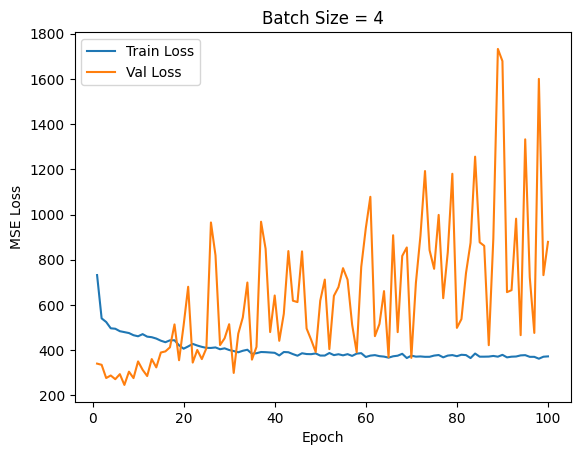

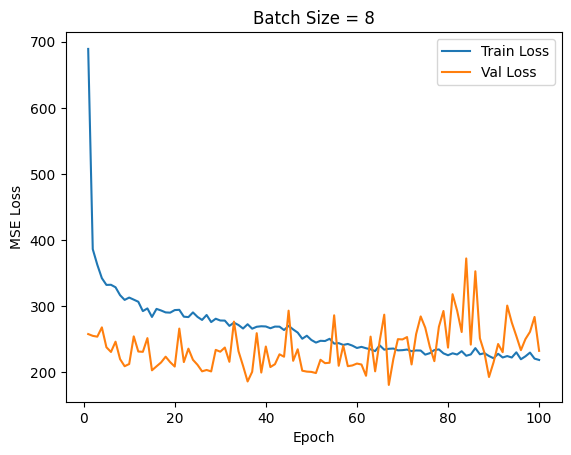

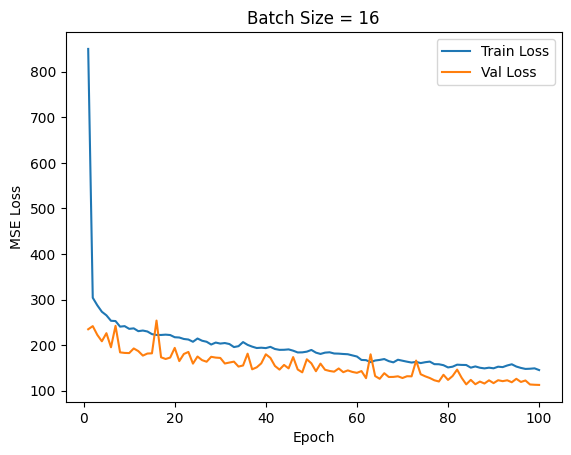

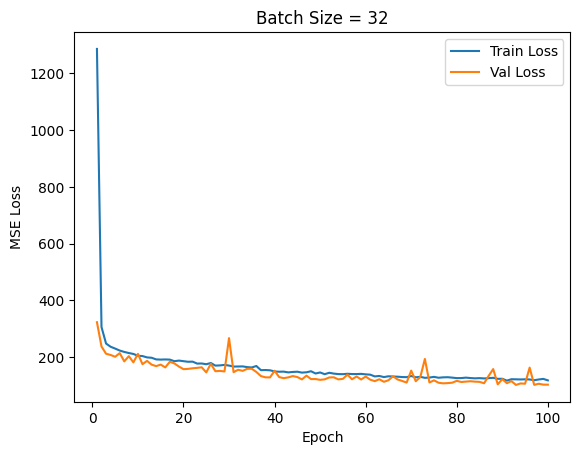

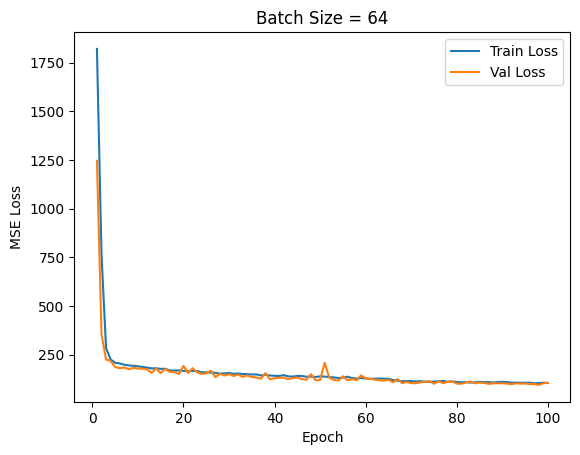

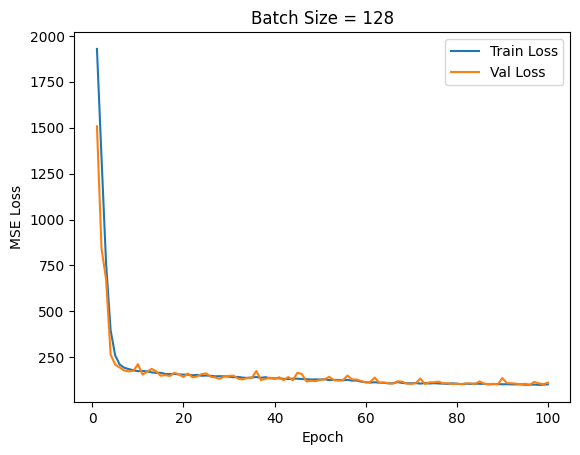

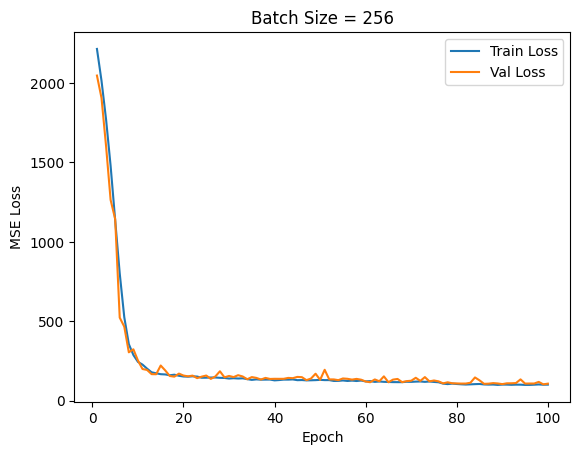


Best Validation MSE by batch size:
BS=  4 | best val MSE = 246.6966
BS=  8 | best val MSE = 180.5155
BS= 16 | best val MSE = 112.8667
BS= 32 | best val MSE = 102.0400
BS= 64 | best val MSE = 94.9769
BS=128 | best val MSE = 99.6198
BS=256 | best val MSE = 102.3646


In [24]:

import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

#Reproducibility

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

#tensors

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val_t   = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t   = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

train_dataset_full = TensorDataset(X_train_t, y_train_t)
val_dataset_full   = TensorDataset(X_val_t, y_val_t)

#model factory
def make_model():
    return SuperconductivityRegressorBN(input_dim=81).to(device)

# loss

criterion = nn.MSELoss()

def run_one_epoch_train(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    n = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        bs = xb.size(0)
        total_loss += loss.item() * bs
        n += bs
    return total_loss / n

@torch.no_grad()
def run_one_epoch_val(model, loader):
    model.eval()
    total_loss = 0.0
    n = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        pred = model(xb)
        loss = criterion(pred, yb)
        bs = xb.size(0)
        total_loss += loss.item() * bs
        n += bs
    return total_loss / n

#training loop
BATCH_SIZES = [4, 8, 16, 32, 64, 128, 256]
EPOCHS = 100
LR = 1e-3
WEIGHT_DECAY = 1e-4

histories = {}
trained_models = {} 

for bs in BATCH_SIZES:
    print(f"\nTraining with batch size = {bs}")

    train_loader = DataLoader(train_dataset_full, batch_size=bs, shuffle=True)
    val_loader   = DataLoader(val_dataset_full, batch_size=bs, shuffle=False)

    model = make_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=10
    )

    train_losses = []
    val_losses = []
    best_val = float("inf")
    best_state = None

    for epoch in range(1, EPOCHS + 1):
        tr = run_one_epoch_train(model, train_loader, optimizer)
        va = run_one_epoch_val(model, val_loader)

        train_losses.append(tr)
        val_losses.append(va)

        scheduler.step(va)

        if va < best_val:
            best_val = va
            best_state = copy.deepcopy(model.state_dict())

        if epoch in [1, 2, 3, 5, 10, 20, 50, 100]:
            current_lr = optimizer.param_groups[0]["lr"]
            print(f"Epoch {epoch:3d} | train MSE: {tr:.4f} | val MSE: {va:.4f} | lr: {current_lr:.2e}")

    #restore best model before saving
    if best_state is not None:
        model.load_state_dict(best_state)

    #complete  history
    histories[bs] = {
        "train": train_losses,
        "val": val_losses,
        "best_val": best_val,
        "best_state": best_state
    }

    #store trained best model
    trained_models[bs] = model

print("\nTraining completed for all batch sizes.")

#plotting
epochs = np.arange(1, EPOCHS + 1)

for bs in BATCH_SIZES:
    plt.figure()
    plt.plot(epochs, histories[bs]["train"], label="Train Loss")
    plt.plot(epochs, histories[bs]["val"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"Batch Size = {bs}")
    plt.legend()
    plt.show()

print("\nBest Validation MSE by batch size:")
for bs in BATCH_SIZES:
    print(f"BS={bs:3d} | best val MSE = {histories[bs]['best_val']:.4f}")


###Task-6: Test Set Evaluation [1 Mark]

For each model trained in Task-5, perform inference on the test set.

(i) Compute the following metrics:

- Mean Squared Error (MSE)

- R² score

(ii) Tabulate the MSE and R² scores for all batch sizes

In [26]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

#test tensors/dataset
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)
test_dataset = TensorDataset(X_test_t, y_test_t)

@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    preds, trues = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        out = model(xb)
        preds.append(out.detach().cpu())
        trues.append(yb.detach().cpu())
    y_pred = torch.cat(preds, dim=0).numpy().reshape(-1)
    y_true = torch.cat(trues, dim=0).numpy().reshape(-1)
    return y_pred, y_true

def mse_np(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

def r2_np(y_true, y_pred):
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    return 1.0 - (ss_res / ss_tot)

#Evaluate each batch size model

BATCH_SIZES = [4, 8, 16, 32, 64, 128, 256]

results = []
for bs in BATCH_SIZES:
    #use best weights
    model = SuperconductivityRegressorBN(input_dim=81).to(device)
    model.load_state_dict(histories[bs]["best_state"])

    test_loader = DataLoader(test_dataset, batch_size=bs, shuffle=False)
    y_pred, y_true = predict_all(model, test_loader)

    test_mse = mse_np(y_true, y_pred)
    test_r2  = r2_np(y_true, y_pred)

    results.append((bs, test_mse, test_r2))

#Print table 
print("\nTest Set Evaluation")
print("-" * 60)
print(f"{'Batch Size':>10} | {'Test MSE':>12} | {'Test R²':>12}")
print("-" * 60)

best_bs, best_mse, best_r2 = None, None, -1e9
for bs, m, r in results:
    print(f"{bs:>10} | {m:>12.4f} | {r:>12.4f}")
    if r > best_r2:
        best_r2 = r
        best_bs = bs
        best_mse = m

print("-" * 60)
print(f"Best by R²: batch_size={best_bs} | Test R²={best_r2:.4f} | Test MSE={best_mse:.4f}")



Test Set Evaluation
------------------------------------------------------------
Batch Size |     Test MSE |      Test R²
------------------------------------------------------------
         4 |     256.9946 |       0.7767
         8 |     196.5454 |       0.8292
        16 |     135.5061 |       0.8823
        32 |     125.7867 |       0.8907
        64 |     120.1738 |       0.8956
       128 |     121.2888 |       0.8946
       256 |     126.5136 |       0.8901
------------------------------------------------------------
Best by R²: batch_size=64 | Test R²=0.8956 | Test MSE=120.1738


###Task-7: Batch Size vs Performance Analysis [1 Mark]

(i) Plot the R² score as a function of batch size

(ii) Explain your observations from this plot

(iii) Which batch size achieves the lowest R^2 score and why?

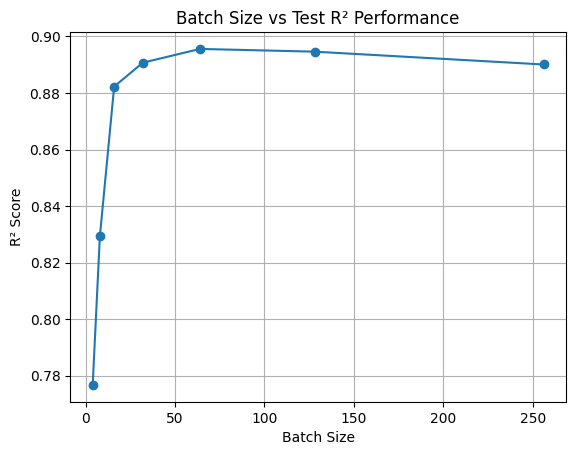

In [27]:
import matplotlib.pyplot as plt

# Extract batch sizes and R² scores from Task-6 results
batch_sizes = [r[0] for r in results]
r2_scores   = [r[2] for r in results]

plt.figure()
plt.plot(batch_sizes, r2_scores, marker='o')
plt.xlabel("Batch Size")
plt.ylabel("R² Score")
plt.title("Batch Size vs Test R² Performance")
plt.grid(True)
plt.show()


The R² score varies with batch size because batch size affects how the model learns during training, very small batch sizes  produce noisy gradient updates, which makes training unstable and leads to poorer generalization, resulting in lower R² scores. Medium batch sizes provide a good balance between gradient stability and learning flexibility, allowing the model to find better minima and achieve higher R² performance. Very large batch sizes reduce gradient noise too much, causing the model to converge to sharper solutions that may not generalize well, so the R² score slightly decreases. therefore, lowest R² is typically observed at the smallest batch size because of high training variance and unstable optimization..


###Task-8: Prediction Scatter Plot [0.5 Marks]

Show the scatter plot of the predictions of the models trained with the batch size that achieves the best R^2 score on the test set vs. ground truths

Best batch size (highest R²): 64


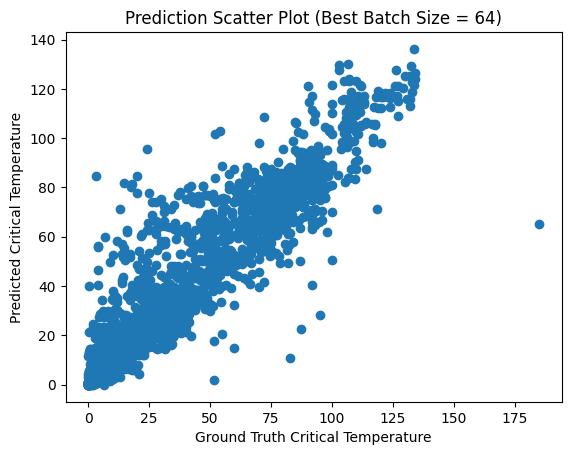

In [29]:
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

#Find batch size with BEST R²

best_bs = max(results, key=lambda x: x[2])[0]
print("Best batch size (highest R²):", best_bs)

#Load BEST model weights

best_model = SuperconductivityRegressorBN(input_dim=81).to(device)
best_model.load_state_dict(histories[best_bs]["best_state"])
best_model.eval()

#test loader

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

test_loader = DataLoader(
    torch.utils.data.TensorDataset(X_test_t, y_test_t),
    batch_size=best_bs,
    shuffle=False
)

# predictions

preds, trues = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        out = best_model(xb)
        preds.append(out.cpu())
        trues.append(yb)

y_pred = torch.cat(preds, dim=0).numpy().reshape(-1)
y_true = torch.cat(trues, dim=0).numpy().reshape(-1)

#scatter Plot
plt.figure()
plt.scatter(y_true, y_pred)
plt.xlabel("Ground Truth Critical Temperature")
plt.ylabel("Predicted Critical Temperature")
plt.title(f"Prediction Scatter Plot (Best Batch Size = {best_bs})")
plt.show()



###Task-9: BN using PyTorch [3 Marks]
(i) Implement BN using PyTorch

(ii) Train the model with the batch size that achieved the best R^2 score

(iii) Report the R^2 score obtained with PyTorch’s implementation of batch normalization

(iv) Show the scatter plot

Best batch size (from Task-6): 64
Device: cpu
Epoch   1 | train MSE: 1741.2029 | val MSE: 1187.0797 | lr: 1.00e-03
Epoch   2 | train MSE: 706.7383 | val MSE: 337.1731 | lr: 1.00e-03
Epoch   3 | train MSE: 288.0703 | val MSE: 204.8224 | lr: 1.00e-03
Epoch   5 | train MSE: 213.3977 | val MSE: 204.6417 | lr: 1.00e-03
Epoch  10 | train MSE: 192.6768 | val MSE: 183.5952 | lr: 1.00e-03
Epoch  20 | train MSE: 168.6783 | val MSE: 152.4050 | lr: 1.00e-03
Epoch  50 | train MSE: 139.7586 | val MSE: 146.0019 | lr: 1.00e-03
Epoch 100 | train MSE: 105.5313 | val MSE: 101.1589 | lr: 2.50e-04

PyTorch BN Test R² (batch size 64): 0.8953


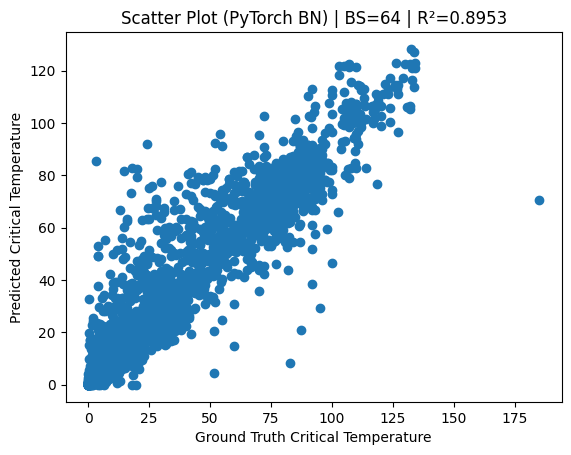

In [31]:
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

#best batch size from task 6
best_bs = max(results, key=lambda x: x[2])[0]
print("Best batch size (from Task-6):", best_bs)

# DataLoadersfor best_bs
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val_t   = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t   = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X_test_t  = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=best_bs, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),     batch_size=best_bs, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),   batch_size=best_bs, shuffle=False)

#PyTorch BN model definition (BatchNorm1d)
#BN placed after Linear and before ReLU
class SuperconductivityRegressorTorchBN(nn.Module):
    def __init__(self, input_dim=81):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.out = nn.Linear(64, 1)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.act(self.bn1(self.fc1(x)))
        x = self.act(self.bn2(self.fc2(x)))
        x = self.act(self.bn3(self.fc3(x)))
        x = self.out(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = SuperconductivityRegressorTorchBN(input_dim=81).to(device)

#train helpers

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=10)

def train_one_epoch(model, loader):
    model.train()
    total_loss, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        bs = xb.size(0)
        total_loss += loss.item() * bs
        n += bs
    return total_loss / n

@torch.no_grad()
def eval_one_epoch(model, loader):
    model.eval()
    total_loss, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = criterion(pred, yb)
        bs = xb.size(0)
        total_loss += loss.item() * bs
        n += bs
    return total_loss / n

# train for 100 epochs
EPOCHS = 100
train_losses, val_losses = [], []
best_val = float("inf")
best_state = None

for epoch in range(1, EPOCHS + 1):
    tr = train_one_epoch(model, train_loader)
    va = eval_one_epoch(model, val_loader)

    train_losses.append(tr)
    val_losses.append(va)

    scheduler.step(va)

    if va < best_val:
        best_val = va
        best_state = copy.deepcopy(model.state_dict())

    if epoch in [1, 2, 3, 5, 10, 20, 50, 100]:
        lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch:3d} | train MSE: {tr:.4f} | val MSE: {va:.4f} | lr: {lr:.2e}")

if best_state is not None:
    model.load_state_dict(best_state)

#compute Test R^2 for PyTorch BN model

@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    preds, trues = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        out = model(xb).detach().cpu()
        preds.append(out)
        trues.append(yb)
    y_pred = torch.cat(preds, dim=0).numpy().reshape(-1)
    y_true = torch.cat(trues, dim=0).numpy().reshape(-1)
    return y_pred, y_true

def r2_np(y_true, y_pred):
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    return 1.0 - (ss_res / ss_tot)

y_pred, y_true = predict_all(model, test_loader)
test_r2 = r2_np(y_true, y_pred)
print(f"\nPyTorch BN Test R² (batch size {best_bs}): {test_r2:.4f}")

#scatter plot: predictions vs ground truths

plt.figure()
plt.scatter(y_true, y_pred)
plt.xlabel("Ground Truth Critical Temperature")
plt.ylabel("Predicted Critical Temperature")
plt.title(f"Scatter Plot (PyTorch BN) | BS={best_bs} | R²={test_r2:.4f}")
plt.show()
